# Notebook 1 — Images and Cameras

- each code cell starts with a **Parameters** section when relevant
- student exercises are marked with **STUDENT TASK**
- blanks to fill use `None` plus a `NotImplementedError`

Run the notebook from top to bottom.


In [1]:
# ============================================
# Setup
# Goal:
# Load the libraries used in the notebook.
# ============================================

# --- Parameters ---
# No parameters in this cell.

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time


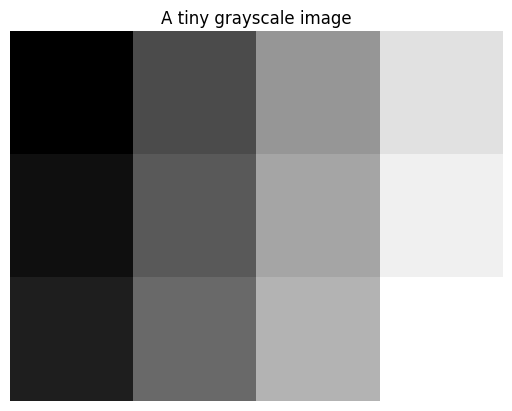

In [2]:
# ============================================
# Example: a tiny grayscale image
# Goal:
# Understand that a grayscale image is a 2D array of numbers.
# ============================================

# --- Parameters ---
IMG_ARRAY = np.array([
    [0,  50, 100, 150],
    [10, 60, 110, 160],
    [20, 70, 120, 170]
], dtype=np.uint8)
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "A tiny grayscale image"

# --- Example code ---
img = IMG_ARRAY.copy()

plt.imshow(img, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

In [3]:
# ============================================
# STUDENT TASK 1
# Goal:
# Access one pixel value in the image.
# ============================================

# --- Parameters ---
TARGET_ROW = 1
TARGET_COL = 2

# --- Fill in the blank ---
# Replace None with code that reads the pixel at (TARGET_ROW, TARGET_COL).
pixel_value = img[TARGET_ROW, TARGET_COL] 

if pixel_value is None:
    raise NotImplementedError("Replace `None` with your code before running this cell.")

print("Pixel value:", pixel_value)

Pixel value: 110


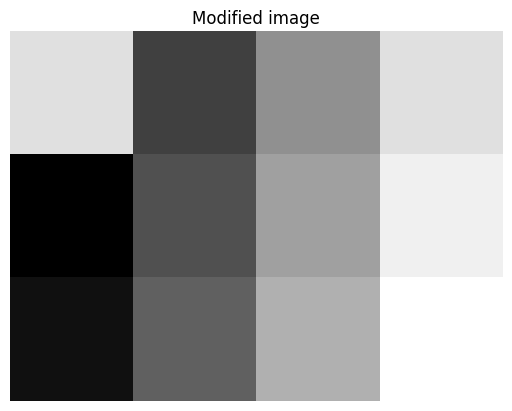

In [4]:
# ============================================
# STUDENT TASK 2
# Goal:
# Modify one pixel, then display the updated image.
# ============================================

# --- Parameters ---
TARGET_ROW = 0
TARGET_COL = 0
NEW_VALUE = 255
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Modified image"

# --- Fill in the blank ---
# Replace None with the value you want to assign to img[TARGET_ROW, TARGET_COL].
value_to_write = 150

if value_to_write is None:
    raise NotImplementedError("Replace `None` with your answer before running this cell.")

img[TARGET_ROW, TARGET_COL] = value_to_write

plt.imshow(img, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

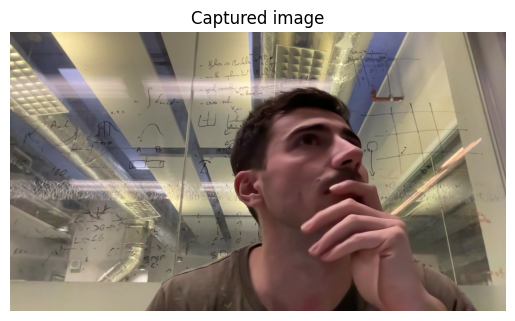

In [5]:
# ============================================
# Capture an image from your camera
# Goal:
# Take one picture using the default camera and display it.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
WARMUP_FRAMES = 20
SAVE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Captured image"

# --- Camera capture ---
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    for _ in range(WARMUP_FRAMES):
        ret, frame = cap.read()

    cap.release()

    if not ret:
        print("Failed to capture image.")
    else:
        cv2.imwrite(SAVE_PATH, frame)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.imshow(rgb)
        plt.title(DISPLAY_TITLE)
        plt.axis("off")
        plt.show()

OpenCV loads images in BGR format (not RGB).
shape (H, W, C): (3000, 4000, 3)
dtype: uint8


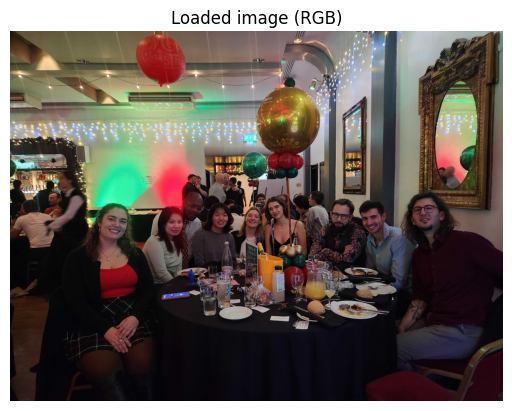

In [6]:
# ============================================
# Load a real image
# Goal:
# Understand how a color image is stored as a 3D array (H, W, C) (Height, Width, Channels).
# ============================================

# --- Parameters ---
IMAGE_PATH = "../images/lab_photo.png"
DISPLAY_TITLE = "Loaded image (RGB)"

# --- Load image ---
bgr = cv2.imread(IMAGE_PATH)

if bgr is None:
    raise FileNotFoundError(f"Couldn't load {IMAGE_PATH}. Make sure the file exists.")

print("OpenCV loads images in BGR format (not RGB).")
print("shape (H, W, C):", bgr.shape)
print("dtype:", bgr.dtype)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()


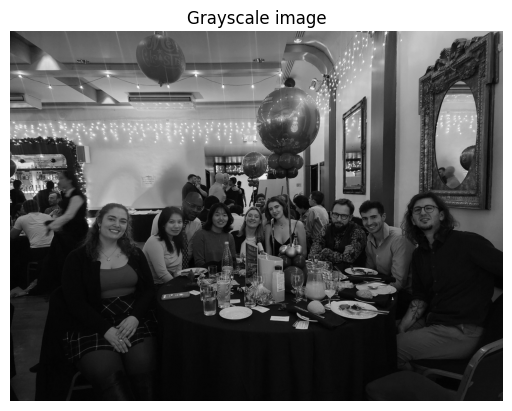

In [7]:
# ============================================
# Convert the image to grayscale
# Goal:
# See the difference between a color image and a 1-channel image.
# ============================================

# --- Parameters ---
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Grayscale image"

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

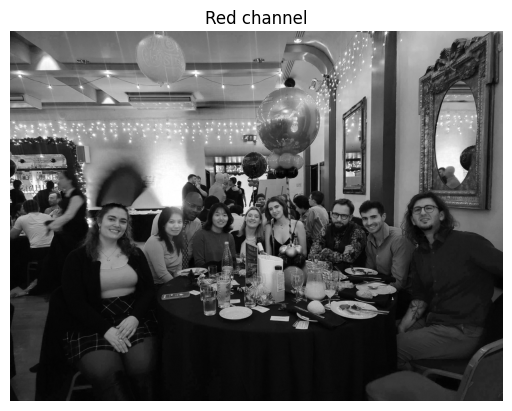

In [8]:
# ============================================
# Example: extract one color channel
# Goal:
# Access the red channel of an RGB image.
# ============================================

# --- Parameters ---
CHANNEL_INDEX = 0   # In RGB: 0=Red, 1=Green, 2=Blue
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Red channel"

red_channel = rgb[:, :, CHANNEL_INDEX]

plt.imshow(red_channel, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

In [9]:
# ============================================
# STUDENT TASK 3
# Goal:
# Extract the blue channel from the RGB image.
# ============================================

# --- Parameters ---
BLUE_CHANNEL_INDEX = 2
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Blue channel"

# --- Fill in the blank ---
# Replace None with code that extracts channel BLUE_CHANNEL_INDEX from rgb.
blue_channel = None

if blue_channel is None:
    raise NotImplementedError("Replace `None` with your code before running this cell.")

plt.imshow(blue_channel, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

NotImplementedError: Replace `None` with your code before running this cell.

Saved: ../pictures/captured_frame_red_filtered.png


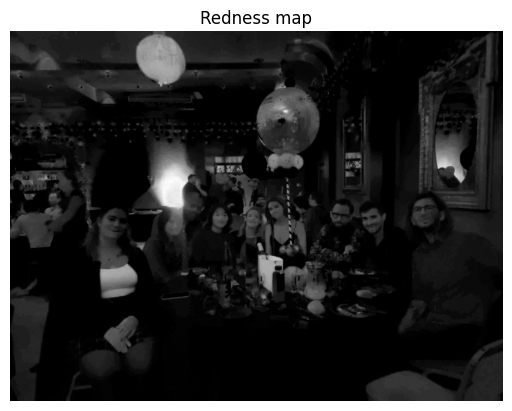

In [10]:
# ============================================
# Example: redness map
# Goal:
# Highlight areas where red is stronger than green and blue.
# ============================================

# --- Parameters ---
RED_WEIGHT = 1.0
OTHER_CHANNEL_WEIGHT = 0.5
OUTPUT_PATH = "../pictures/captured_frame_red_filtered.png"
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Redness map"

R = rgb[:, :, 0].astype(float)
G = rgb[:, :, 1].astype(float)
B = rgb[:, :, 2].astype(float)

redness = RED_WEIGHT * R - OTHER_CHANNEL_WEIGHT * (G + B)
redness = redness.clip(0, 255).astype("uint8")

cv2.imwrite(OUTPUT_PATH, redness)
print("Saved:", OUTPUT_PATH)

plt.imshow(redness, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

In [11]:
# ============================================
# STUDENT TASK 4
# Goal:
# Build a blueness map using the same idea as the redness map.
# ============================================

# --- Parameters ---
BLUE_WEIGHT = 1.0
OTHER_CHANNEL_WEIGHT = 0.5
OUTPUT_PATH = "../pictures/captured_frame_blue_filtered.png"
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Blueness map"

R = rgb[:, :, 0].astype(float)
G = rgb[:, :, 1].astype(float)
B = rgb[:, :, 2].astype(float)

# --- Fill in the blank ---
# Replace None with an expression that is high when blue is dominant.
blueness_float = None

if blueness_float is None:
    raise NotImplementedError("Replace `None` with your formula before running this cell.")

blueness = blueness_float.clip(0, 255).astype("uint8")

cv2.imwrite(OUTPUT_PATH, blueness)
print("Saved:", OUTPUT_PATH)

plt.imshow(blueness, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("off")
plt.show()

NotImplementedError: Replace `None` with your formula before running this cell.

## Live video example — red channel

In [12]:
# ============================================
# Live video: red channel
# Goal:
# Display the red channel from the camera in real time.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 3
WINDOW_NAME = "Red Channel"

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            red_channel = frame[:, :, 2]  # OpenCV uses BGR

            cv2.imshow(WINDOW_NAME, red_channel)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)


## Live video example — redness map

In [17]:
# ============================================
# Live video: redness map
# Goal:
# Compute and display a redness map frame by frame.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 3
WINDOW_NAME = "Live Redness Map"
RED_WEIGHT = 1.0
OTHER_CHANNEL_WEIGHT = 0.5

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            R = rgb[:, :, 0].astype(float)
            G = rgb[:, :, 1].astype(float)
            B = rgb[:, :, 2].astype(float)

            redness = RED_WEIGHT * R - OTHER_CHANNEL_WEIGHT * (G + B)
            redness = redness.clip(0, 255).astype("uint8")

            cv2.imshow(WINDOW_NAME, redness)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)


## Live video example — false colors

In [18]:
# ============================================
# Live video: redness map with a false-color colormap
# Goal:
# Make weak/strong red regions easier to see.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 5
WINDOW_NAME = "Live Redness Map"
COLORMAP = cv2.COLORMAP_HOT   # Try: COLORMAP_JET, COLORMAP_TURBO, COLORMAP_VIRIDIS
RED_WEIGHT = 1.0
OTHER_CHANNEL_WEIGHT = 0.5

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            R = rgb[:, :, 0].astype(float)
            G = rgb[:, :, 1].astype(float)
            B = rgb[:, :, 2].astype(float)

            redness = RED_WEIGHT * R - OTHER_CHANNEL_WEIGHT * (G + B)
            redness = redness.clip(0, 255).astype("uint8")

            colored_redness = cv2.applyColorMap(redness, COLORMAP)
            cv2.imshow(WINDOW_NAME, colored_redness)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(1) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)


## Final question

Which colormap do you prefer, and why?
